In [2]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# # Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# # Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# # kagglehub.dataset_download('<owner>/<dataset-slug>')

In [3]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import os

In [4]:
data_dir = '/kaggle/input/datasets/mosabbirahmed/intel-image-classification-no-splits/intel_dataset'

In [5]:
mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15), # Slight rotations to help the model generalize
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [6]:
full_train_dataset = datasets.ImageFolder(data_dir, transform=train_transforms)
full_test_dataset = datasets.ImageFolder(data_dir, transform=test_val_transforms)

In [7]:
class_names = full_train_dataset.classes
print(f"Classes found: {class_names}")

Classes found: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [8]:
num_samples = len(full_train_dataset)
num_samples

16900

In [9]:
# 4. Split into Train (70%), Val (15%), Test (15%)
num_samples = len(full_train_dataset)
indices = list(range(num_samples))
np.random.seed(42)
np.random.shuffle(indices)

train_split = int(np.floor(0.7 * num_samples))
val_split = int(np.floor(0.85 * num_samples))

train_idx = indices[:train_split]
val_idx = indices[train_split:val_split]
test_idx = indices[val_split:]

In [10]:
# Apply the splits
train_data = Subset(full_train_dataset, train_idx)
val_data = Subset(full_test_dataset, val_idx)
test_data = Subset(full_test_dataset, test_idx)

In [11]:
# 5. Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=2)

In [12]:
print(f"Training samples: {len(train_data)}")
print(f"Validation samples: {len(val_data)}")
print(f"Testing samples: {len(test_data)}")

Training samples: 11830
Validation samples: 2535
Testing samples: 2535


In [13]:
torch.cuda.is_available()

True

In [14]:
import torch.nn as nn
import torch.nn.functional as F

class IntelImageCNN(nn.Module):
    def __init__(self, num_classes=6):
        super(IntelImageCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        
        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        self.dropout = nn.Dropout(p=0.5) 
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        
        x = x.view(-1, 128 * 28 * 28)
        
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x) 
        
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = IntelImageCNN(num_classes=6).to(device)

print(model)
print(f"Model is running on: {device}")

IntelImageCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=100352, out_features=512, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=6, bias=True)
)
Model is running on: cuda


In [17]:
import torch.optim as optim
import matplotlib.pyplot as plt
import time
from tqdm.notebook import tqdm  # Added tqdm for Jupyter/Kaggle environments

# 1. Define Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 2. Tracking History for Curves
num_epochs = 10
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_loss = float('inf')
model_save_path = 'best_intel_cnn_model.pth'

print(f"Starting training on {device} for {num_epochs} epochs...\n")

for epoch in range(num_epochs):
    start_time = time.time()
    
    # --- TRAINING PHASE ---
    model.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0
    
    # Wrap train_loader with tqdm
    train_progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False)
    
    for images, labels in train_progress:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += torch.sum(preds == labels.data).item()
        total_train += labels.size(0)
        
        # Update the progress bar with the current loss
        train_progress.set_postfix({'loss': f"{loss.item():.4f}"})
        
    epoch_train_loss = running_train_loss / total_train
    epoch_train_acc = (correct_train / total_train) * 100.0

    # --- VALIDATION PHASE ---
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    # Wrap val_loader with tqdm
    val_progress = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False)
    
    with torch.no_grad(): 
        for images, labels in val_progress:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct_val += torch.sum(preds == labels.data).item()
            total_val += labels.size(0)
            
            val_progress.set_postfix({'loss': f"{loss.item():.4f}"})
            
    epoch_val_loss = running_val_loss / total_val
    epoch_val_acc = (correct_val / total_val) * 100.0
    
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)
    
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), model_save_path)
        checkpoint_msg = " [Saved Best Model]"
    else:
        checkpoint_msg = ""
        
    elapsed = time.time() - start_time
    print(f"Epoch [{epoch+1:02d}/{num_epochs:02d}] ({elapsed:.1f}s) | "
          f"Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc:.2f}%{checkpoint_msg}")

print(f"\nTraining completed! Best model saved to: {model_save_path}")

Starting training on cuda for 10 epochs...



Epoch 1/10 [Train]:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 1/10 [Val]:   0%|          | 0/80 [00:00<?, ?it/s]

Epoch [01/10] (54.0s) | Train Loss: 0.7755 - Train Acc: 71.45% | Val Loss: 0.6311 - Val Acc: 77.00% [Saved Best Model]


Epoch 2/10 [Train]:   0%|          | 0/370 [00:00<?, ?it/s]

...

Epoch 9/10 [Val]:   0%|          | 0/80 [00:00<?, ?it/s]

Epoch [09/10] (34.9s) | Train Loss: 0.3689 - Train Acc: 87.13% | Val Loss: 0.4257 - Val Acc: 85.25%


Epoch 10/10 [Train]:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/80 [00:00<?, ?it/s]

Epoch [10/10] (35.1s) | Train Loss: 0.3498 - Train Acc: 87.53% | Val Loss: 0.4405 - Val Acc: 85.40%

Training completed! Best model saved to: best_intel_cnn_model.pth


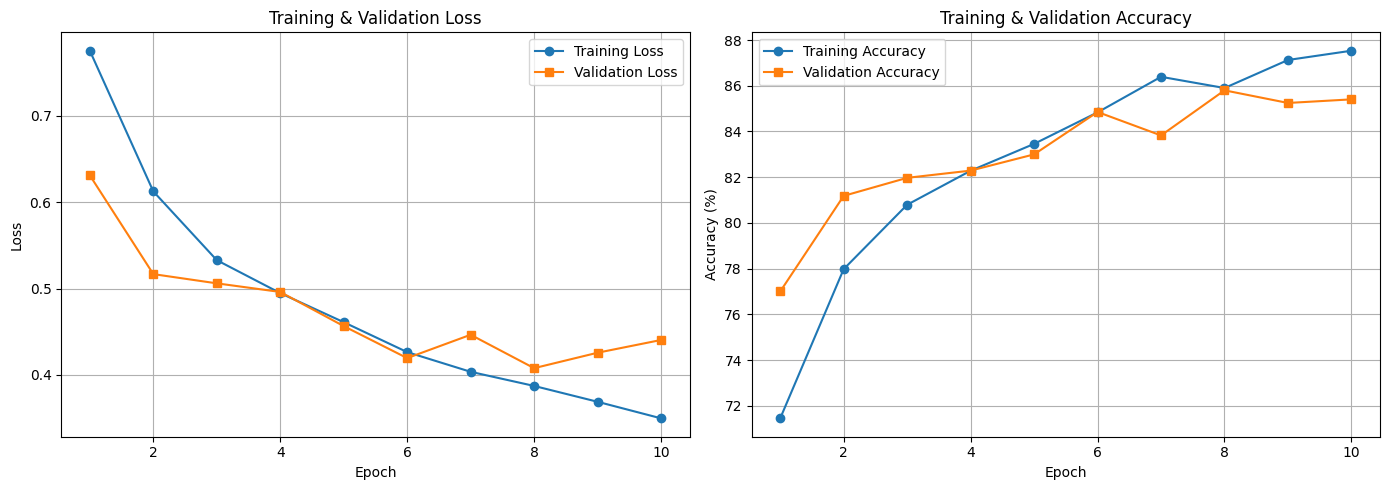

In [18]:
# 3. Plotting Training and Validation Curves
epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(14, 5))

# Loss Curves
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Training Loss', marker='o')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', marker='s')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy Curves
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], label='Training Accuracy', marker='o')
plt.plot(epochs_range, history['val_acc'], label='Validation Accuracy', marker='s')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('loss_accuracy_curves.png')
plt.show()

Running evaluation on the test set...

--- Classification Report ---
              precision    recall  f1-score   support

   buildings       0.79      0.87      0.83       395
      forest       0.97      0.94      0.96       409
     glacier       0.84      0.83      0.84       436
    mountain       0.82      0.85      0.84       457
         sea       0.89      0.86      0.88       435
      street       0.87      0.82      0.85       403

    accuracy                           0.86      2535
   macro avg       0.87      0.86      0.86      2535
weighted avg       0.87      0.86      0.86      2535



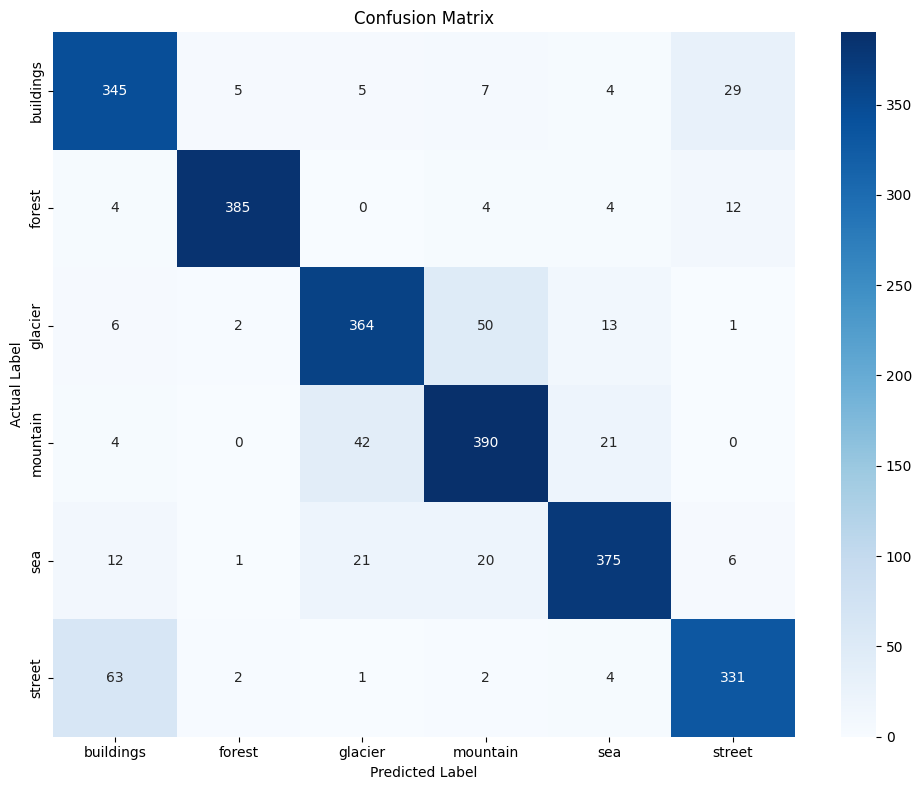

In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Load the Best Model Weights
model.load_state_dict(torch.load('best_intel_cnn_model.pth'))
model.eval()

all_preds = []
all_labels = []

print("Running evaluation on the test set...")

# 2. Gather Predictions
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 3. Generate Classification Report (Accuracy, Precision, Recall, F1-Score)
class_names = full_train_dataset.classes
print("\n--- Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=class_names))

# 4. Generate and Plot Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

# Step 6: Results Analysis

## 1. Overall Performance
* **Overall Accuracy:** 86% across 2,535 test samples.
* **Macro Average F1-Score:** 0.86, showing balanced performance across all 6 classes.

## 2. Strengths & Weaknesses
* **Top Performer (`forest`):** Achieved the highest metrics (Precision: 0.97, Recall: 0.94, F1-score: 0.96).
* **Lowest Performer (`buildings`):** Struggled the most, yielding the lowest precision (0.79) and F1-score (0.83).
* **Natural Landscapes (`glacier`, `mountain`, `sea`):** Maintained consistent, moderate performance (F1: 0.84 to 0.88).

## 3. Key Misclassifications
* **Street vs. Buildings:** 63 `street` images were misclassified as `buildings`, and 29 `buildings` were labeled as `street`. Urban scenes often contain overlapping elements like roads and concrete structures, causing confusion.
* **Glacier vs. Mountain:** 50 `glacier` images were classified as `mountain`, and 42 `mountain` images as `glacier`. This is expected due to the high visual overlap in snowy and rocky topographies.

## 4. Proposed Improvements
To fulfill the requirement of suggesting practical upgrades to increase model performance[cite: 1]:
* **Transfer Learning:** Fine-tune a pre-trained model (such as ResNet-50) to better capture complex, high-level features in visually similar classes.
* **Targeted Augmentation:** Introduce specialized augmentations like color jittering, localized cropping, or perspective shifts to force the model to learn structural differences beyond basic colors.